## LAB № 3
-----

Implement the Kalman filter by sigma points for the given task.

Task: find the position in 1D space, we use data from the camera, measuring the height of distant landmarks relative to the horizon.<br />
Important!
1.) Keep the same linear motion model as in the original
example, and assume that we know the height of the landmark and its position in the global coordinate system.
2.) Because our sensor measures an angle, our measurement model is non-linear with position
moving object.

<img src="https://likerobotics.ru/images/task2.jpg" width="400"/>

### Initial Data

An object's state is defined by its **position** and **velocity**.  
The control input is the **acceleration**.

State

$$
\mathbf{x} =
\begin{bmatrix}
p \\
\dot{p} = \frac{dp}{dt}
\end{bmatrix}
$$

Control input

$$
\mathbf{u} = a = \frac{d^2 p}{dt^2}
$$

Motion model
$$
\begin{aligned}
\mathbf{x}_{k} &=\mathbf{f}\left(\mathbf{x}_{k-1}, \mathbf{u}_{k-1}, \mathbf{w}_{k-1}\right) \\
&=\left[\begin{array}{cc}
1 & \Delta t \\
0 & 1
\end{array}\right] \mathbf{x}_{k-1}+\left[\begin{array}{c}
0 \\
\Delta t
\end{array}\right] \mathbf{u}_{k-1}+\mathbf{w}_{k-1} \\
v_{k} & \sim \mathscr{N}(0,0.01) \quad \mathbf{w}_{k} \sim \mathscr{N}\left(\mathbf{0},(0.1) \mathbf{1}_{2 \times 2}\right)
\end{aligned}
$$

Measurment model
$$
\begin{aligned}
y_{k} &=\phi_{k}=h\left(p_{k}, v_{k}\right) \\
&=\tan ^{-1}\left(\frac{S}{D-p_{k}}\right)+v_{k}
\end{aligned}
$$

Find the position of the object at the moment
time 𝒌 + 𝟏, with ∆𝒕 = 𝟎. 𝟓 sec

$$
\begin{array}{cl}
\hat{\mathbf{x}}_{0} \sim \mathscr{N}\left(\left[\begin{array}{l}
0 \\
5
\end{array}\right],\right. & \left.\left[\begin{array}{cc}
0.01 & 0 \\
0 & 1
\end{array}\right]\right) \\
u_{0}=-2\left[\mathrm{~m} / \mathrm{s}^{2}\right] & y_{1}=\pi / 6[\mathrm{rad}] \\
S=20[\mathrm{~m}] & D=40[\mathrm{~m}]
\end{array}
$$

In [ ]:
import numpy as np
from numpy.linalg import inv, cholesky
import matplotlib.pyplot as plt

In [ ]:
x_0 = np.array([[0],[5]])
P_0 = np.array([[0.01 , 0],
                [0, 1]]) #covariance at time 0
Q_0 = np.array([[0.1 , 0],
                [0, 0.1]]) #covariance of the motion model at time 0
R_0 = 0.01 #measurement model covariance at time 0
u_0 = -2
y_1 = np.pi/6
S = 20
D = 40
dt = 0.5
def motion_iterate(dt, x_k, u_k):
    """
    example inputs:
    dt = 0.5
    x_k = 0
    u_k = -2
    """
    # motion model
    x_matrix = np.array([[1, dt], [0, 1]])
    u_matrix = np.array([[0], [dt]])
    x_k = x_matrix.dot(x_k) + u_matrix*u_k
    return x_k

Remember, for an N dimensional distribution, we need to take N+1 sigma points.

In [ ]:
#Cholesky decomposition for covariance matrix
N = 2 # distribution dimension
ka = 3 - N # каппа, value for normal distribution
hol = cholesky(P_0)
print(hol)
#sigma point to be found
sigma_list = []
sigma_list.append(x_0)
#....

# Calculate the scaling factor
scale = np.sqrt(N + ka)

# Generate symmetric sigma points (following the formulas from your image)
for i in range(N):

# Generate symmetric sigma points
    sigma_plus = x_0 + scale * hol[:, i].reshape(-1, 1)
    sigma_list.append(sigma_plus)

    sigma_minus = x_0 - scale * hol[:, i].reshape(-1, 1)
    sigma_list.append(sigma_minus)


# Convert to numpy array for better visualization
#sigma_points = np.array(sigma_list).T

#....
print(sigma_list)

[[0.1 0. ]
 [0.  1. ]]
[array([[0],
       [5]]), array([[0.17320508],
       [5.        ]]), array([[-0.17320508],
       [ 5.        ]]), array([[0.        ],
       [6.73205081]]), array([[0.        ],
       [3.26794919]])]


In [ ]:
# now we pass our sigma points through a non-linear function (motion model)
# to get the sigma point for time k
sigma_predicted = np.zeros((len(sigma_list), 2, 1))
for i, sigma in enumerate(sigma_list):
  sigma_predicted[i] = motion_iterate(dt, sigma, u_0)
    # sigma_predicted[i] = ...
sigma_predicted

array([[[2.5       ],
        [4.        ]],

       [[2.67320508],
        [4.        ]],

       [[2.32679492],
        [4.        ]],

       [[3.3660254 ],
        [5.73205081]],

       [[1.6339746 ],
        [2.26794919]]])

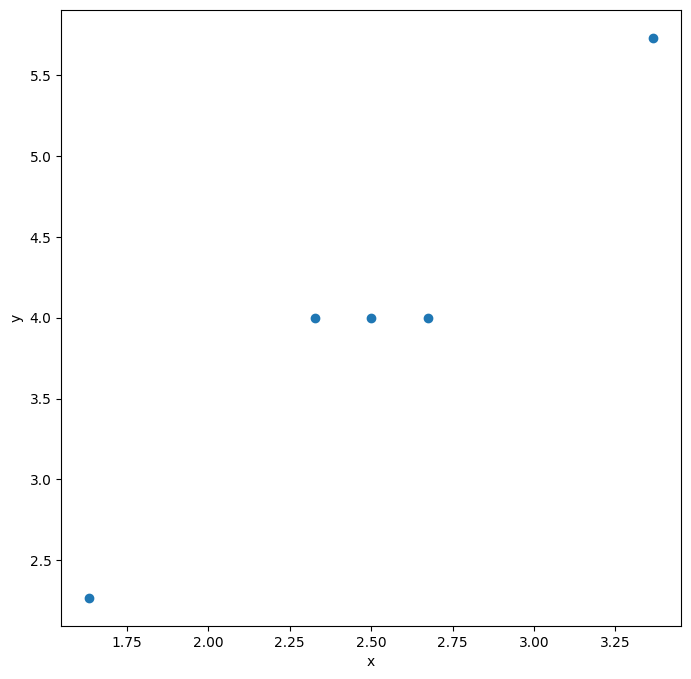

In [ ]:
plt.figure(figsize=(8, 8))
plt.scatter(sigma_predicted[:,0], sigma_predicted[:,1])
# plt.scatter(mean_x, mean_y, color='red', s=300)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# well, now we calculate the output (predicted) mean and output covariance

#coefficients to be calculated.
# Calculate weights (a_list) - CORRECTED VERSION
a_list = [ka/(N+ka)]  # Weight for i=0
for i in range(1, 2*N + 1):
    a_list.append(1/(2*(N + ka)))  # Weights for i=1...2N

#initialize variables for the new distribution
x_new = np.array([[0.0],[0.0]])
P_new = np.array([[0.0, 0.0],[0.0, 0.0]])

#mean of the new distribution

# Calculate predicted mean (x_new)
for i in range(2*N + 1):
    x_new += a_list[i] * sigma_predicted[i]

#covariance of the new distribution

# Calculate predicted covariance (P_new)
for i in range(2*N + 1):
    diff = sigma_predicted[i] - x_new
    P_new += a_list[i] * np.dot(diff, diff.T)

# Add process noise covariance
P_new += Q_0

print("The new mean = ", x_new)
print("The new covariance = ", P_new)

The new mean =  [[2.5]
 [4. ]]
The new covariance =  [[0.36 0.5 ]
 [0.5  1.1 ]]


## Now, knowing our prediction, when we take a measurement, we can make a correction
similar procedure, only this time with a non-linear measurement model
$$
\hat{\mathbf{y}}_{k}^{(i)}=\mathbf{h}_{k}\left(\check{\mathbf{x}}_{k}^{(i)}, \mathbf{0}\right) \quad i=0 \ldots 2 N
$$

In [ ]:
#decomposition of our P_new
hol = cholesky(P_new)
print(hol)

# similarly find the sigma point
cor_sigma_list = []

cor_sigma_list.append(x_new)
for i in range(N):
    cor_sigma_list.append(x_new + np.sqrt(N + ka) * hol[:, i].reshape(-1, 1))
    cor_sigma_list.append(x_new - np.sqrt(N + ka) * hol[:, i].reshape(-1, 1))

print(cor_sigma_list)


[[0.6        0.        ]
 [0.83333333 0.63683244]]
[array([[2.5],
       [4. ]]), array([[3.53923048],
       [5.44337567]]), array([[1.46076952],
       [2.55662433]]), array([[2.5       ],
       [5.10302614]]), array([[2.5       ],
       [2.89697386]])]


In [ ]:
def measure_iterate(S,D,pk):
    """
    example inputs:
    S = 0.5
    D = 0
    p_k = -2
    """
    # motion model
    y_k = np.arctan(S/(D-pk))
    return y_k

p_k = cor_sigma_list[0][0][0]
measure_iterate(S,D,p_k)

np.float64(0.4899573262537283)

In [ ]:
# similarly run through the model
sigma_mes_list = []

for sigma in cor_sigma_list:
    p_k = sigma[0][0]  # Extract position from state vector
    sigma_mes_list.append(measure_iterate(S, D, p_k))

print(sigma_mes_list)

[np.float64(0.4899573262537283), np.float64(0.5017175820877777), np.float64(0.4786937816119785), np.float64(0.4899573262537283), np.float64(0.4899573262537283)]


Теперь считаем среднюю и ковариацию

In [ ]:
#mean of the new distribution

# Calculate mean of predicted measurement
y_new = 0.0
for i, a in enumerate(a_list):
    y_new += a * sigma_mes_list[i]

# Calculate measurement covariance
P_y_new = 0.0
for i, a in enumerate(a_list):
    diff = sigma_mes_list[i] - y_new
    P_y_new += a * (diff * diff)  # scalar multiplication for 1D measurement
P_y_new += R_0  # Add measurement noise

print("The new mean = ", y_new)
print("The new covariance = ", P_y_new)

The new mean =  0.4900401114524449
The new covariance =  0.010044188322474038


We calculate the cross covariance, Kalman amplifier and get the final value of the estimate

In [ ]:
P_xy = np.zeros((2, 1))
for i, a in enumerate(a_list):
    x_diff = cor_sigma_list[i] - x_new
    y_diff = sigma_mes_list[i] - y_new
    P_xy += a * (x_diff * y_diff)  # (2x1) * scalar
print(P_xy)

[[0.00398784]
 [0.00553867]]


In [ ]:
#gain
K = P_xy * (1/P_y_new)
K

array([[0.39702952],
       [0.55142988]])

In [ ]:
# final estimation after correction
x_1 = x_new + K * (y_1 - y_new)
print(x_1)

[[2.51332378]
 [4.01850525]]


In [ ]:
P_1 = P_new - (K * P_y_new) @ K.T
print(P_1)

[[0.35841671 0.49780099]
 [0.49780099 1.09694581]]
